In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import pickle
import arviz as az
import arviz_plots as azp
from matplotlib.lines import Line2D


In [2]:


paths = [f"../Models/asthma_7_year_repeat{j}_fold{i}.nc" for i in range(3) for j in range(2)]
trees = [az.from_netcdf(p) for p in paths]

# Stack the parameter posteriors across folds
combined_posterior_7 = xr.concat([t["posterior"].to_dataset() for t in trees], dim="chain",
)

list_parameters=["$NO_x$","$NO_2$","Formaldehyd","Acetone","Acetald","Black Carbon","$PM_{2.5}$","Street $NO_2$","Street $NO_x$","Street $PM_{2.5}$","Gestational age","Asthma risk score"]
combined_posterior_7 = combined_posterior_7.assign_coords(weight_dim_0=list_parameters)
combined_posterior_7["weight_OR"]=np.exp(combined_posterior_7["weight"])
asthma_7 = xr.DataTree.from_dict({"posterior": combined_posterior_7})


In [3]:


paths = [f"../Models/asthma_12_year_repeat{j}_fold{i}.nc" for i in range(3) for j in range(2)]
trees = [az.from_netcdf(p) for p in paths]

# Stack the parameter posteriors across folds
combined_posterior_12 = xr.concat([t["posterior"].to_dataset() for t in trees], dim="chain",
)


list_parameters=["$NO_x$","$NO_2$","Formaldehyd","Acetone","Acetald","Black Carbon","$PM_{2.5}$","Street $NO_2$","Street $NO_x$","Street $PM_{2.5}$","Gestational age","LRTI","Asthma risk score"]
combined_posterior_12 = combined_posterior_12.assign_coords(weight_dim_0=list_parameters)
combined_posterior_12["weight_OR"]=np.exp(combined_posterior_12["weight"])
asthma_12 = xr.DataTree.from_dict({"posterior": combined_posterior_12})

In [4]:


paths = [f"../Models/asthma_18_year_repeat{j}_fold{i}.nc" for i in range(3) for j in range(2)]
trees = [az.from_netcdf(p) for p in paths]

# Stack the parameter posteriors across folds
combined_posterior_18 = xr.concat([t["posterior"].to_dataset() for t in trees], dim="chain",
)
list_parameters=["$NO_x$","$NO_2$","Formaldehyd","Acetone","Acetald","Black Carbon","$PM_{2.5}$","Street $NO_2$","Street $NO_x$","Street $PM_{2.5}$","Gestational age","LRTI","Asthma risk score"]
combined_posterior_18 = combined_posterior_18.assign_coords(weight_dim_0=list_parameters)
combined_posterior_18["weight_OR"]=np.exp(combined_posterior_18["weight"])
asthma_18 = xr.DataTree.from_dict({"posterior": combined_posterior_18})


/data/michaelf/miniconda3/envs/Numpyro_clinical_regression/lib/python3.14/site-packages/arviz_plots/plot_collection.py:56: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'weight_dim_0' ('weight_dim_0',) The recommendation is to set join explicitly for this case.
  data = xr.concat(ds_list, dim="model").assign_coords(model=list(data))


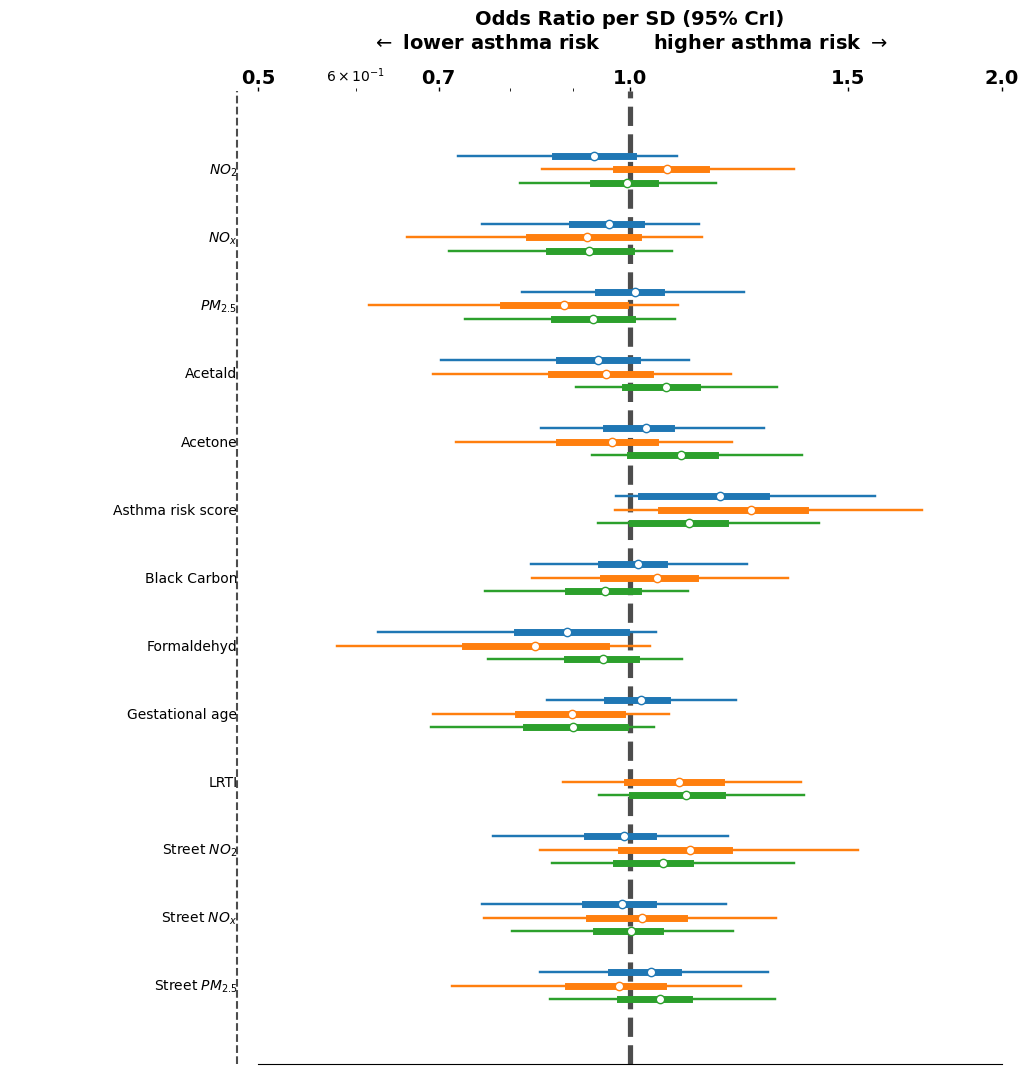

In [5]:


# ============================================================
# Helper: features whose 95% CrI excludes OR = 1
# ============================================================
def excludes_one(idata, var_name="weight_OR", prob=0.95):
    s = az.summary(idata, var_names=[var_name], hdi_prob=prob)
    hdi_cols = sorted([c for c in s.columns if c.startswith("hdi_")])
    lo, hi = hdi_cols[0], hdi_cols[-1]
    mask = (s[lo] > 1) | (s[hi] < 1)
    return {idx.split("[")[-1].rstrip("]") for idx in s.index[mask]}



# ============================================================
# Forest plot — alternate row shading via shade_label
# ============================================================
pc = azp.plot_forest(
    {"Asthma 7y": asthma_7, "Asthma 12y": asthma_12, "Asthma 18y": asthma_18},
    combined=True,
    var_names="weight_OR",
    shade_label="__variable__",                 # native alternate shading
    visuals={"shade": {"color": "0.55"}},       # gray; alpha 0/0.3 alternates
)

# Reference line at OR = 1
pc = azp.add_lines(
    pc,
    values=[1.0],
    visuals={"ref_line": {"color": "0.3", "linestyle": "--", "linewidth": 1.5}},
)

forest_ax = pc.viz["plot"].sel(column="forest").item()
labels_ax = pc.viz["plot"].sel(column="labels").item()
fig = forest_ax.figure

# --- Thicken CI lines ---
for line in forest_ax.lines:
    c = line.get_color()
    if c not in ("black", "k", "#000000", (0.0, 0.0, 0.0, 1.0)):
        line.set_linewidth(line.get_linewidth() * 2.5)

# --- Log x-scale ---
forest_ax.set_xscale("log")
forest_ax.set_xlim(0.5, 2.0)
forest_ax.set_xticks([0.5, 0.7, 1.0, 1.5, 2.0])
forest_ax.set_xticklabels(["0.5", "0.7", "1.0", "1.5", "2.0"])

# --- Clean labels (left) axis ---
labels_ax.set_xlabel("")
labels_ax.set_xticks([])
labels_ax.tick_params(axis="x", which="both", length=0, labelbottom=False)
labels_ax.tick_params(axis="y", labelsize=14, length=0, pad=15)
for spine in ("top", "right", "bottom", "left"):
    labels_ax.spines[spine].set_visible(False)

# Bold consistent features; mute the rest
for tl in labels_ax.get_yticklabels():
    tl.set_horizontalalignment("right")
    if tl.get_text() in consistent:
        tl.set_fontweight("bold")
        tl.set_color("black")
    else:
        tl.set_fontweight("normal")
        tl.set_color("0.30")

# --- Clean forest axis ---
for spine in ("top", "right", "left"):
    forest_ax.spines[spine].set_visible(False)

forest_ax.tick_params(axis="y", length=0, labelleft=False)
forest_ax.tick_params(axis="x", labelsize=14, pad=0)
forest_ax.set_ylabel("")
forest_ax.set_xlabel(
    "Odds Ratio per SD (95% CrI)\n"
    r"$\leftarrow$ lower asthma risk        higher asthma risk $\rightarrow$",
    fontsize=14, fontweight="bold", labelpad=12,
)
forest_ax.xaxis.set_label_position("top")
forest_ax.xaxis.tick_top()
for tl in forest_ax.get_xticklabels():
    tl.set_fontweight("bold")

# --- Hide arviz_plots default debris ---
for ax in fig.axes:
    for txt in list(ax.texts):
        if "weight" in txt.get_text().lower() or "dim" in txt.get_text().lower():
            txt.set_visible(False)
    for tl in ax.get_xticklabels():
        if "weight" in tl.get_text():
            tl.set_visible(False)
for txt in list(fig.texts):
    if "weight" in txt.get_text().lower():
        txt.set_vis
fig.savefig("../Plots/arviz.png",bbox_inches="tight")